In [1]:
import numpy as np
from scipy.signal import StateSpace, lsim
import matplotlib.pyplot as plt

# %% Paràmetres

# Geometria
zp = 12
zr = 36
i = zr / zp # relació transmissió

R = 0.1     # radi tambor (m)

# Inèrcies
J_m = 0.02  # kg·m², inèrcia motor
J_p = 0.005 # kg·m², inèrcia pinyò
J_t = 0.5  # kg·m², inèrcia tambor

m_c = 10.0  # kg, massa bloc

# Rigideses
k_t = 160.0 # Nm/rad, rigidesa torsional
k = 40.0e3  # N/m, rigidesa cable

# Dissipació
c_r = 5.0   # Nm·s/rad, rodament A

# Càrregues externes
Mm = 10.0   # Nm, moment motor constant
g = 9.8    # m/s², gravetat

t_f = 1.5  # s, temps final simulació

# %% Model per espai d'estat

# Matriu A
A = np.array([
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1],
    [-k_t/J_m,  i*k_t/J_m, 0,
     -c_r/J_m, 0, 0],
    [ i*k_t/(i**2*J_p + J_t),
     -(i**2*k_t + R**2*k)/(i**2*J_p + J_t),
      R*k/(i**2*J_p + J_t),
      0, 0, 0],
    [0, R*k/m_c, -k/m_c, 0, 0, 0]
])

# Matriu B (3 inputs: Mm, 0, -m_c g)
B = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
    [1/J_m, 0, 0],
    [0, 1/(i**2*J_p + J_t), 0],
    [0, 0, 1/m_c]
])

# Matriu C (sortides)
C = np.array([
    [0, 0, 1, 0, 0, 0],     # posició, x
    [0, 0, 0, 0, 0, 1],     # velocitat, x_dot
    [0, 0, 0, c_r, 0, 0],   # moment dissipat, (c_r * theta_dot_m)
    [0, R, -1, 0, 0, 0]     # elongació, (R*theta_t - x)
])

# Matriu D
D = np.zeros((C.shape[0],B.shape[1]))

# Sistema
sys = StateSpace(A, B, C, D)

# Temps
t = np.linspace(0, t_f, 1000)

# Inputs: [Mm, 0, -m_c*g]
u = np.zeros((len(t), 3))
u[:,0] = Mm
u[:,2] = -m_c * g

# Simulació
t, y, x = lsim(sys, U=u, T=t)

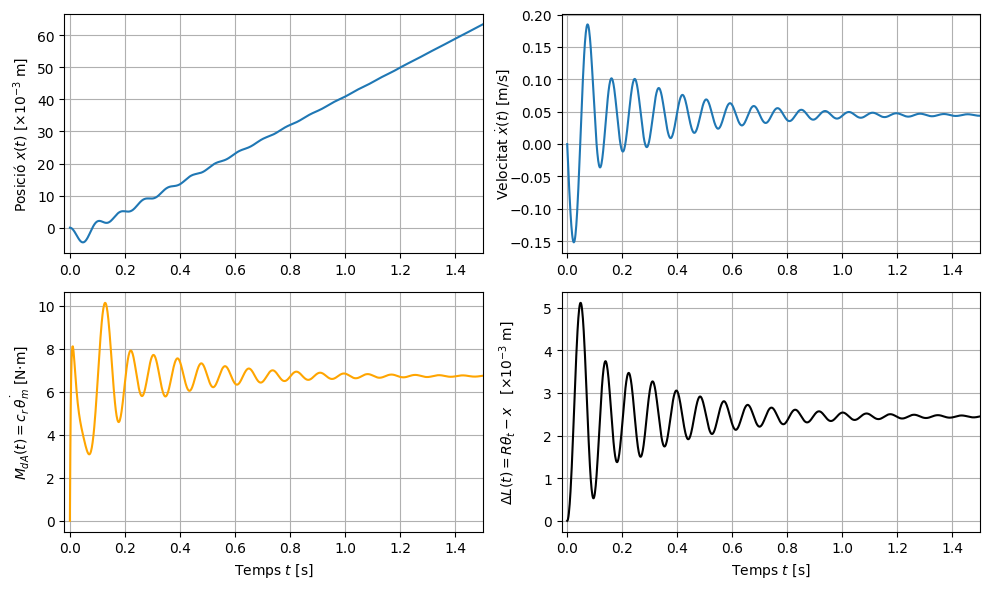

In [2]:
# %% Figura resultats

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# x
axs[0, 0].plot(t, y[:,0]*1e3)
# axs[0, 0].set_xlabel("Temps (s)")
axs[0, 0].set_ylabel(r"Posició $x(t)$ [$\times 10^{-3}$ m]")
axs[0, 0].grid()

# x_dot
axs[0, 1].plot(t, y[:,1])
# axs[0, 1].set_xlabel("Temps (s)")
axs[0, 1].set_ylabel(r"Velocitat $\dot{x}(t)$ [m/s]", labelpad=-2)
axs[0, 1].grid()

# moment dissipat
axs[1, 0].plot(t, y[:,2], color='orange')
axs[1, 0].set_xlabel(r"Temps $t$ [s]")
axs[1, 0].set_ylabel(r"$M_{dA}(t) = c_r \, \dot{\theta_m}$ [N·m]")
axs[1, 0].grid()

# elongació
axs[1, 1].plot(t, y[:,3]*1e3, color='black')
axs[1, 1].set_xlabel(r"Temps $t$ [s]")
axs[1, 1].set_ylabel(r"$\Delta L(t) = R \theta_t - x \;$  [$\times 10^{-3}$ m]"
                     , labelpad=18)
axs[1, 1].grid()

for ax in axs.flat:
    ax.set_xlim([-0.02, t_f])

plt.tight_layout()
# plt.savefig('CME_Exemple_5_5_SOL1.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [3]:
# %% Càlcul dels valors en règim estacionari

dot_theta0  = (Mm - m_c*g*R/i)/(c_r)    # velocitat motor en règim estacionari
dot_x0      = dot_theta0/i*R            # velocitat cable en règim estacionari

M_dA0 = dot_theta0*c_r     # moment dissipat al rodament A en règim estacionari

Delta_L = m_c*g/k           # elongació del cable en règim estacionari

print('\n' + '-'*32)
print('VALORS EN RÈGIM ESTACIONARI')
print('-'*32)
print(f'Velocitat del motor: {dot_theta0:2.2f} rad/s')
print(f'Velocitat del cable: {dot_x0:2.3f} m/s \n')
print(f'Moment dissipat:     {M_dA0:2.2f} Nm')
print(f'Elongació del cable: {m_c*g/k:2.4f} m')
print('-'*32)


--------------------------------
VALORS EN RÈGIM ESTACIONARI
--------------------------------
Velocitat del motor: 1.35 rad/s
Velocitat del cable: 0.045 m/s 

Moment dissipat:     6.73 Nm
Elongació del cable: 0.0024 m
--------------------------------
